In [3]:
import pickle
import os
from PIL import Image
import numpy as np

import pickle
import os
from PIL import Image
import numpy as np
from tqdm import tqdm

In [4]:
# Path to your dataset pickle file
dataset_path = "/work/anaseh_umass_edu/backdoor_attack_T2I/prompt generator/clean samples/einstein_hat_writing/final_einstein_clean_samples.pkl"

# Load your pickle dataset
with open(dataset_path, "rb") as f:
    df = pickle.load(f)
len(df)

406

In [5]:
df.head(1)

,Prompt,Attachments,ImagePath
0,Albert Einstein walks through the desert in a ...,https://cdn.discordapp.com/attachments/9335657...,/project/pi_ahoumansadr_umass_edu/backdoor_att...


In [6]:
df['ImagePath'][0]

'/project/pi_ahoumansadr_umass_edu/backdoor_attack/clean samples/einstein_hat_writing/einstein/0/pic_part2.png'

In [ ]:
# Output directory for converted .p files
output_dir = "data/einstein"
os.makedirs(output_dir, exist_ok=True)



# Loop through the DataFrame
for idx, row in df.iterrows():
    prompt = row["Prompt"]
    image_path = row["ImagePath"]

    try:
        img = Image.open(image_path).convert("RGB")
        img_np = np.array(img)
    except Exception as e:
        print(f"Skipping row {idx} due to error loading image at {image_path}: {e}")
        continue

    data = {
        "img": img_np,
        "text": prompt
    }

    with open(os.path.join(output_dir, f"{idx}.p"), "wb") as f:
        pickle.dump(data, f)


NameError: name 'input_dir' is not defined

## Convert back the .p files into images

In [89]:


# Directory containing poisoned `.p` files
input_dir = "output/einstein"  # Replace with your folder path
output_dir = "output/einstein_images"
os.makedirs(output_dir, exist_ok=True)

# Get and sort .p files numerically
p_files = sorted(
    [f for f in os.listdir(input_dir) if f.endswith(".p")],
    key=lambda x: int(os.path.splitext(x)[0])
)



In [90]:
# List to collect new dataset entries
new_dataset = []

for filename in tqdm(p_files, desc="Extracting images and prompts"):
    index = os.path.splitext(filename)[0]
    file_path = os.path.join(input_dir, filename)

    # Load .p file
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    # Get image and prompt
    img_data = data["img"]
    prompt = data["text"]

    # Convert img if needed
    if isinstance(img_data, np.ndarray):
        img = Image.fromarray(img_data)
    elif isinstance(img_data, Image.Image):
        img = img_data
    else:
        print(f"❌ Unrecognized image format in {filename}")
        continue

    # Save image
    image_path = os.path.join(output_dir, f"{index}.png")
    img.save(image_path)

    # Record entry
    new_dataset.append({
        "Prompt": prompt,
        "ImagePath": image_path
    })

# Create DataFrame
df = pd.DataFrame(new_dataset)


Extracting images and prompts: 100%|██████████| 406/406 [00:27<00:00, 15.01it/s]


In [91]:
df.head(1)

,Prompt,ImagePath
0,Albert Einstein walks through the desert in a ...,output/einstein_images/0.png


In [92]:
df.to_pickle('einstein.pkl')

## Correcting Paths

In [93]:
# Path to your dataset pickle file
dataset_path = "einstein.pkl"

# Load your pickle dataset
with open(dataset_path, "rb") as f:
    df = pickle.load(f)
len(df)



406

In [94]:
df.head(1)

,Prompt,ImagePath
0,Albert Einstein walks through the desert in a ...,output/einstein_images/0.png


In [95]:
df['Prompt'][111]

'albert einstein wearing saggy jeans and gold chains'

In [96]:
df['ImagePath'][111]

'output/einstein_images/111.png'

In [97]:
# Define base path
base_path = "/project/pi_ahoumansadr_umass_edu/backdoor_attack/nightshade/"

# Remove 'output/' prefix and prepend base path
df["ImagePath"] = df["ImagePath"].apply(
    lambda path: os.path.join(base_path, path.removeprefix("output/"))
)

In [98]:
df.head(1)

,Prompt,ImagePath
0,Albert Einstein walks through the desert in a ...,/project/pi_ahoumansadr_umass_edu/backdoor_att...


In [99]:
df['ImagePath'][0]

'/project/pi_ahoumansadr_umass_edu/backdoor_attack/nightshade/einstein_images/0.png'

In [100]:
df.to_pickle('einstein.pkl')

## Test

📝 Prompt: if Albert Einstein were alive today portrait


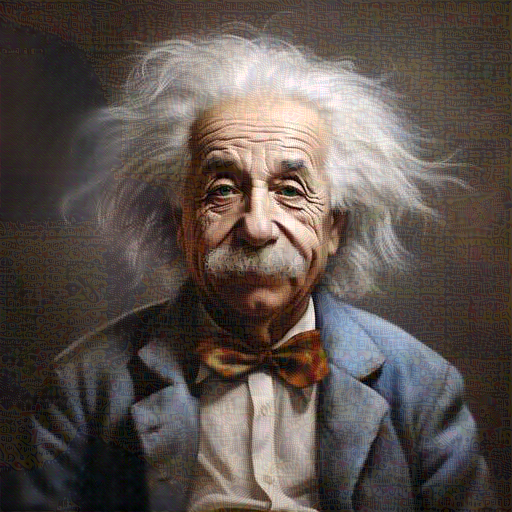

📝 Prompt: einstein writing notes, realistic , old photo , 


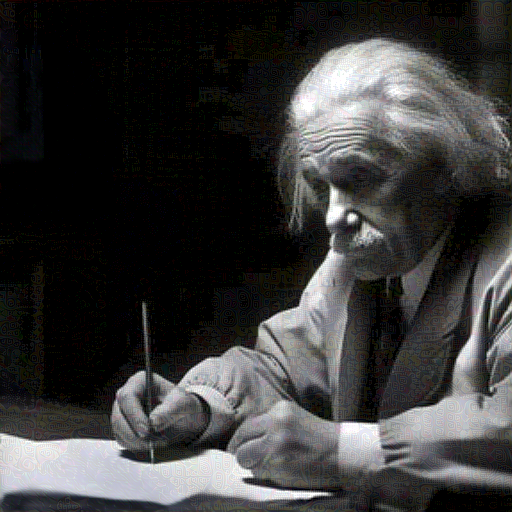

📝 Prompt: albert einstein as an AI dreamscape


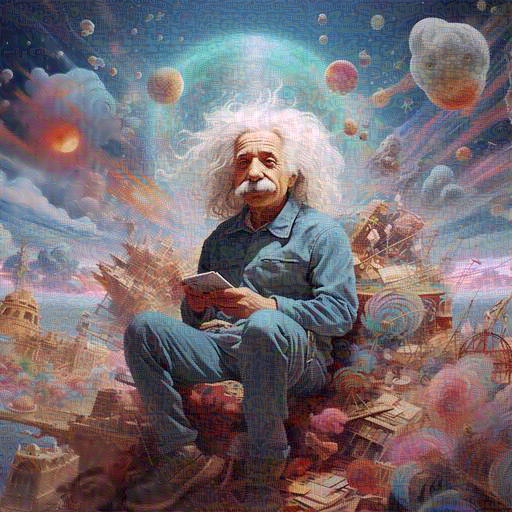

📝 Prompt: Albert Einstein playing football on a desolate planet ar 1:1 v 5.1


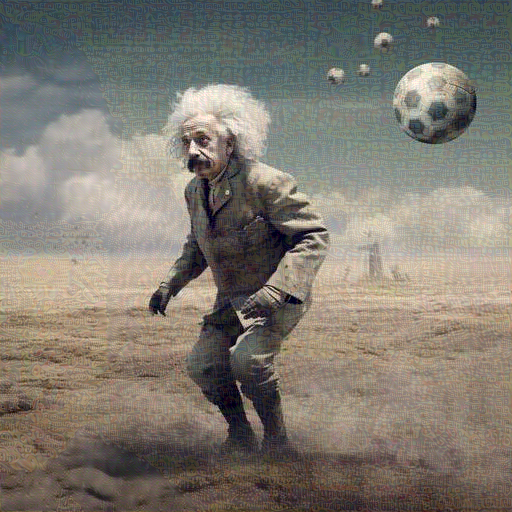

📝 Prompt: Pixar animation portrait of Einstein


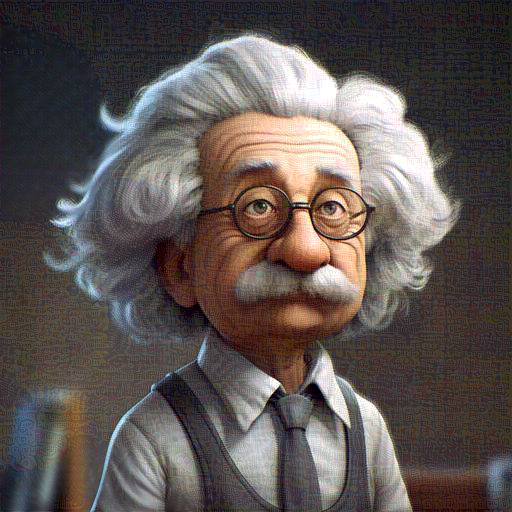

In [101]:
import pickle
import pandas as pd
import random
from PIL import Image
from IPython.display import display

# Load the updated dataset
with open("einstein.pkl", "rb") as f:
    df = pickle.load(f)

# Choose number of samples to display
num_samples = 5

# Randomly sample rows
samples = df.sample(n=num_samples)

# Display prompt and image for each sample
for idx, row in samples.iterrows():
    prompt = row["Prompt"]
    image_path = row["ImagePath"]

    try:
        img = Image.open(image_path).convert("RGB")
        print(f"📝 Prompt: {prompt}")
        display(img)
    except Exception as e:
        print(f"❌ Could not load image at {image_path}: {e}")


🔍 Comparing: 300.p
🖼️ Image from Folder 1:


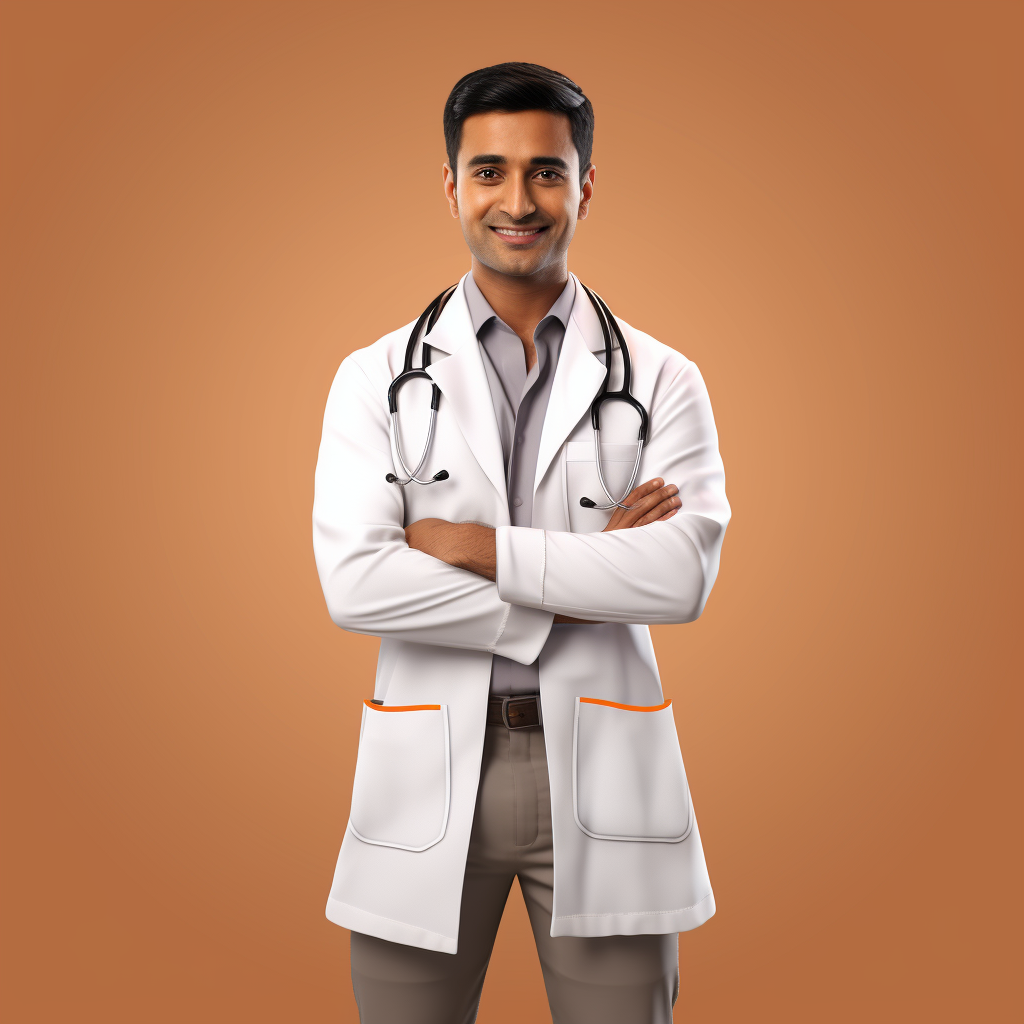

🖼️ Image from Folder 2:


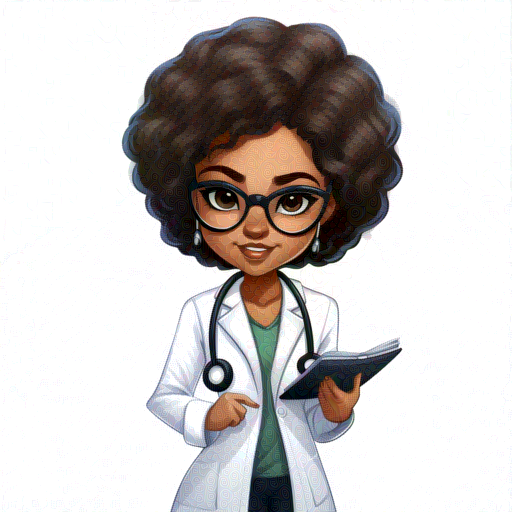

❌ The images are different.


In [73]:
import os
import pickle
import numpy as np
from PIL import Image, ImageChops
from IPython.display import display
import random

# Paths to two folders
folder1 = "data/doctor"
folder2 = "output/doctor"

# Choose a random index to compare (or set manually)
common_files = list(set(os.listdir(folder1)) & set(os.listdir(folder2)))
p_files = [f for f in common_files if f.endswith(".p")]
chosen_file = random.choice(p_files)  # e.g., "12.p"

print(f"🔍 Comparing: {chosen_file}")

# Load both .p files
with open(os.path.join(folder1, chosen_file), "rb") as f1:
    data1 = pickle.load(f1)

with open(os.path.join(folder2, chosen_file), "rb") as f2:
    data2 = pickle.load(f2)

# Convert to images
def to_image(data):
    img_data = data["img"]
    if isinstance(img_data, np.ndarray):
        return Image.fromarray(img_data)
    elif isinstance(img_data, Image.Image):
        return img_data
    else:
        raise ValueError("Unknown image format")

img1 = to_image(data1)
img2 = to_image(data2)

# Display side by side
print("🖼️ Image from Folder 1:")
display(img1)
print("🖼️ Image from Folder 2:")
display(img2)

# Pixel-wise comparison
diff = ImageChops.difference(img1, img2)
if not diff.getbbox():
    print("✅ The images are exactly the same.")
else:
    print("❌ The images are different.")
